In [99]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

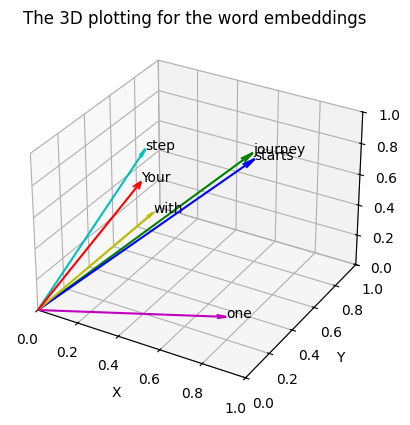

In [100]:
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D 

words = ["Your", "journey", "starts", "with", "one", "step"]

x_coordinates = inputs[:, 0].numpy()
y_coordinates = inputs[: , 1].numpy()
z_coordinates = inputs[: , 2].numpy()
colors = ['r', 'g' ,'b', 'y', 'm', 'c']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x,y,z,word,color in zip(x_coordinates, y_coordinates, z_coordinates, words, colors):
    ax.quiver(0,0,0,x,y,z, color=color, arrow_length_ratio=0.05)
    ax.text(x,y,z, word, fontsize=10)
    

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])


plt.title("The 3D plotting for the word embeddings")
plt.show()

In [101]:
query = inputs[1]

atten_scores = torch.empty(inputs.shape[0]) 

for i, i_x in enumerate(inputs):
    atten_scores[i] = torch.dot(i_x, query)
    
print(atten_scores)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [102]:
atten_weights = atten_scores / atten_scores.sum(axis=0)

print(atten_weights)
print(atten_weights.sum())

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
tensor(1.0000)


In [103]:
def softmax_navie(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

print(softmax_navie(atten_scores))
softmax_navie(atten_scores).sum(dim=0)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


tensor(1.)

In [104]:
atten_weights = torch.softmax(atten_scores, dim=0)
print(torch.softmax(atten_scores, dim=0))

print(torch.softmax(atten_scores, dim=0).sum(dim=0))

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


In [105]:
context_vec2 = torch.zeros(query.shape)
for i,j in zip(inputs, atten_weights):
    context_vec2 += i * j

print(context_vec2) ## For the Journey..

tensor([0.4419, 0.6515, 0.5683])


In [106]:
attention_scores = inputs @ inputs.T ## attention score matrix ! 

print(attention_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [107]:
attention_weights = torch.softmax(attention_scores, dim=1)
print(attention_weights) ## attention weight matrix !! 

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [108]:
### Just verifying 

print(attention_weights.sum(dim=1)) ## each row should sum up to 1

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [109]:
## Context Vector Matrix

context_vectors = attention_weights @ inputs

print(context_vectors)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [110]:
### Lets instantiate the trainable matrices 

torch.manual_seed(123)
K = torch.nn.Parameter(torch.rand(3,2))

Q = torch.nn.Parameter(torch.rand(3,2))

V = torch.nn.Parameter(torch.rand(3,2))

In [111]:
### Input embedding Vectors are turned into three matrices 

keys = inputs @ K
queries = inputs @ Q
values = inputs @ V

In [112]:
attention_scores_qk = queries @ keys.T

attention_scores_qk

tensor([[0.9231, 1.2705, 1.2544, 0.6973, 0.6114, 0.8995],
        [1.3545, 1.8524, 1.8284, 1.0167, 0.8819, 1.3165],
        [1.3241, 1.8111, 1.7877, 0.9941, 0.8626, 1.2871],
        [0.7910, 1.0795, 1.0654, 0.5925, 0.5121, 0.7682],
        [0.4032, 0.5577, 0.5508, 0.3061, 0.2707, 0.3937],
        [1.1330, 1.5440, 1.5238, 0.8475, 0.7307, 1.0996]],
       grad_fn=<MmBackward0>)

In [117]:
key_dim = K.shape[-1]
print(key_dim)


attention_weights_qk = torch.softmax(attention_scores_qk / key_dim ** 0.5 , dim=0)
attention_weights_qk

2


tensor([[0.1551, 0.1500, 0.1503, 0.1591, 0.1610, 0.1557],
        [0.2104, 0.2264, 0.2256, 0.1994, 0.1949, 0.2092],
        [0.2059, 0.2199, 0.2192, 0.1962, 0.1923, 0.2048],
        [0.1413, 0.1311, 0.1315, 0.1477, 0.1501, 0.1419],
        [0.1074, 0.0906, 0.0914, 0.1206, 0.1265, 0.1089],
        [0.1799, 0.1820, 0.1819, 0.1769, 0.1752, 0.1794]],
       grad_fn=<SoftmaxBackward0>)

In [121]:
### Context vectors 

context_vectors_ = attention_weights_qk @ values

print(context_vectors_)

tensor([[0.2586, 0.6988],
        [0.3602, 0.9737],
        [0.3518, 0.9509],
        [0.2325, 0.6283],
        [0.1740, 0.4697],
        [0.3021, 0.8169]], grad_fn=<MmBackward0>)
